In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("nyc_housing_base.csv")

In [3]:
df

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34434,5,7316,4,850000,10309.0,SI,1996.0,3180.0,1300.0,1300.0,0.0,2.0,2.0,2.0,40.535457,-74.223370,1.0,B9,29.0
34435,5,7317,130,855000,10309.0,SI,1995.0,3700.0,2500.0,2500.0,0.0,2.0,2.0,3.0,40.535470,-74.222060,1.0,B9,30.0
34436,5,7359,3,1200000,10309.0,SI,2001.0,4359.0,2200.0,2200.0,0.0,2.0,2.0,2.0,40.531791,-74.222555,1.0,B2,24.0
34437,5,6998,6,800000,10309.0,QN,1950.0,2185.0,1458.0,1458.0,0.0,1.0,1.0,2.0,40.726143,-73.800272,1.0,A5,75.0


In [4]:
df.isnull().sum()

borough_x         0
block             0
lot               0
sale_price        0
zip_code         16
borough_y         0
yearbuilt         0
lotarea           0
bldgarea          0
resarea         188
comarea         188
unitsres          0
unitstotal        0
numfloors        43
latitude          6
longitude         6
landuse           3
bldgclass         0
building_age      0
dtype: int64

In [5]:
df.fillna(df.mean(numeric_only = True),inplace = True)
df.drop_duplicates(inplace = True)

In [6]:
df = df.drop(columns = ["borough_x","block","lot","zip_code","borough_y"])

In [7]:
df

,sale_price,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,280000,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,2000000,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,3400000,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,4000000,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,655000,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34434,850000,1996.0,3180.0,1300.0,1300.0,0.0,2.0,2.0,2.0,40.535457,-74.223370,1.0,B9,29.0
34435,855000,1995.0,3700.0,2500.0,2500.0,0.0,2.0,2.0,3.0,40.535470,-74.222060,1.0,B9,30.0
34436,1200000,2001.0,4359.0,2200.0,2200.0,0.0,2.0,2.0,2.0,40.531791,-74.222555,1.0,B2,24.0
34437,800000,1950.0,2185.0,1458.0,1458.0,0.0,1.0,1.0,2.0,40.726143,-73.800272,1.0,A5,75.0


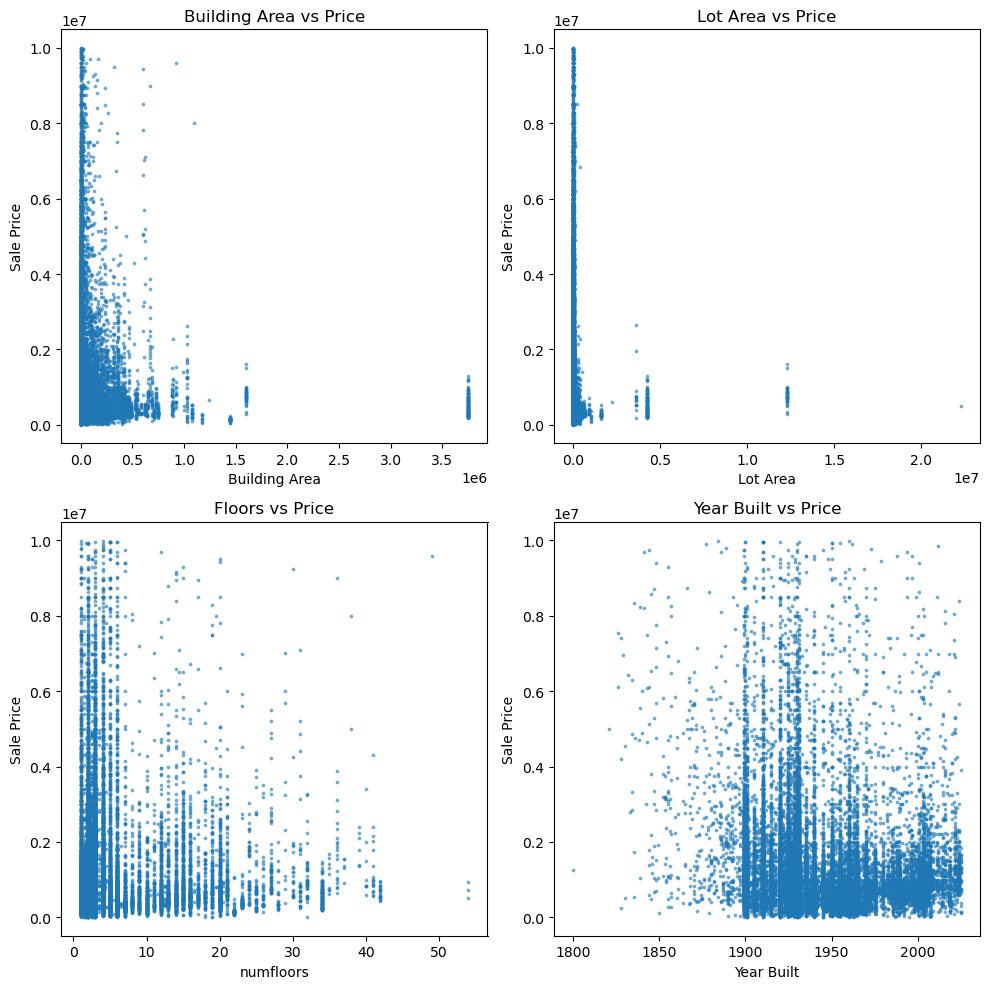

In [8]:
fig,ax = plt.subplots(2,2, figsize = (10,10))
ax[0,0].scatter(df["bldgarea"], df["sale_price"],s =3, alpha = 0.5)
ax[0,0].set_title("Building Area vs Price")
ax[0,0].set_xlabel("Building Area")
ax[0,0].set_ylabel("Sale Price")

ax[0,1].scatter(df["lotarea"], df["sale_price"],s = 3, alpha = 0.5)
ax[0,1].set_title("Lot Area vs Price")
ax[0,1].set_xlabel("Lot Area")
ax[0,1].set_ylabel("Sale Price")

ax[1,0].scatter(df["numfloors"], df["sale_price"],s = 3, alpha = 0.5)
ax[1,0].set_title("Floors vs Price")
ax[1,0].set_xlabel("numfloors")
ax[1,0].set_ylabel("Sale Price")

ax[1,1].scatter(df["yearbuilt"], df["sale_price"],s = 3 , alpha = 0.5)
ax[1,1].set_title("Year Built vs Price")
ax[1,1].set_xlabel("Year Built")
ax[1,1].set_ylabel("Sale Price")

plt.tight_layout()
plt.show()


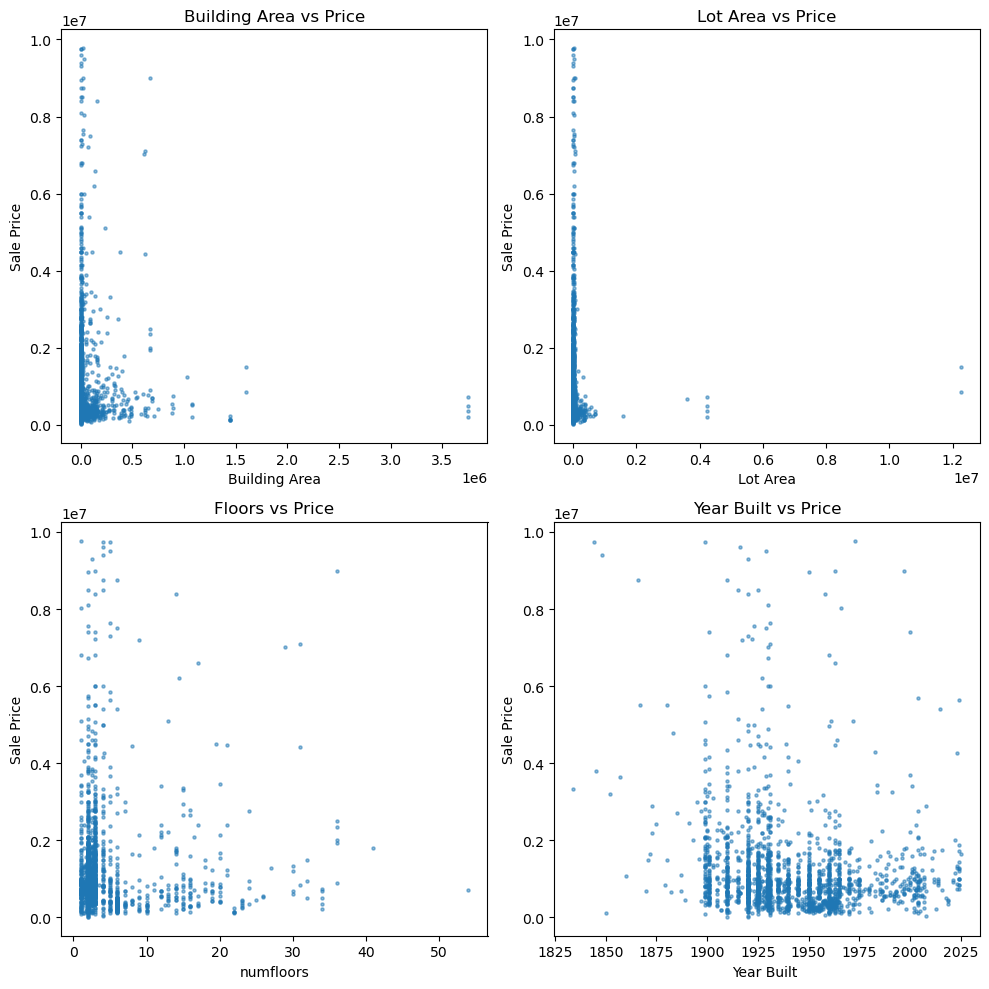

In [9]:
sample_df = df.sample(2000,random_state = 42)
fig,ax = plt.subplots(2,2, figsize = (10,10))
ax[0,0].scatter(sample_df["bldgarea"], sample_df["sale_price"],s =5, alpha = 0.5)
ax[0,0].set_title("Building Area vs Price")
ax[0,0].set_xlabel("Building Area")
ax[0,0].set_ylabel("Sale Price")

ax[0,1].scatter(sample_df["lotarea"],sample_df["sale_price"],s = 5, alpha = 0.5)
ax[0,1].set_title("Lot Area vs Price")
ax[0,1].set_xlabel("Lot Area")
ax[0,1].set_ylabel("Sale Price")

ax[1,0].scatter(sample_df["numfloors"],sample_df["sale_price"],s = 5, alpha = 0.5)
ax[1,0].set_title("Floors vs Price")
ax[1,0].set_xlabel("numfloors")
ax[1,0].set_ylabel("Sale Price")

ax[1,1].scatter(sample_df["yearbuilt"], sample_df["sale_price"],s = 5 , alpha = 0.5)
ax[1,1].set_title("Year Built vs Price")
ax[1,1].set_xlabel("Year Built ")
ax[1,1].set_ylabel("Sale Price")

plt.tight_layout()
plt.show()

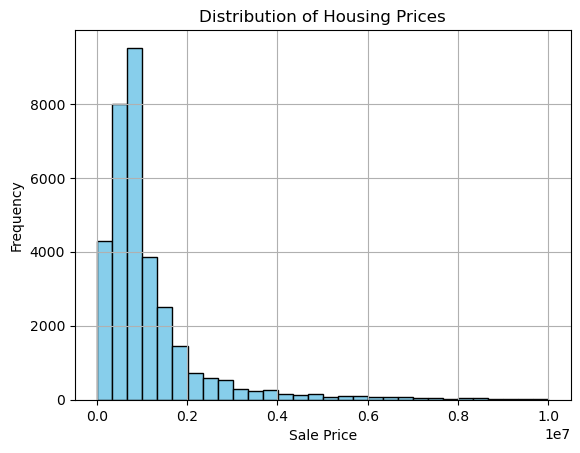

In [10]:

plt.hist(df["sale_price"],color = "skyblue",edgecolor = "black", bins=30)
plt.title("Distribution of Housing Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [11]:
df.corr(numeric_only = True)["sale_price"].sort_values(ascending = False)

sale_price      1.000000
building_age    0.132110
landuse         0.119960
latitude        0.009637
numfloors      -0.017483
comarea        -0.022284
lotarea        -0.040852
bldgarea       -0.074661
resarea        -0.087355
unitstotal     -0.114162
unitsres       -0.115728
longitude      -0.116752
yearbuilt      -0.132110
Name: sale_price, dtype: float64

In [29]:
x = df[["yearbuilt","landuse","longitude","unitsres"]]
y = df["sale_price"]

In [30]:
x = x.values
y = y.values

In [31]:
x = (x-x.mean(axis = 0))/x.std(axis = 0)
y= (y-y.mean())/y.std()

In [43]:
class LinearRegression:
    def __init__(self, learning_rate = 0.01, n_iter = 5000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    def fit(self,x,y):
        m, n = x.shape
        
        self.bias = 0
        self.weights = np.zeros(n)

        for i in range(self.n_iter):
            y_pred = self.bias + np.dot(x,self.weights)

            db = (1/m) * np.sum(y_pred -y)
            dw = (1/m) * np.dot(x.T,(y_pred-y))

            self.bias -= self.lr * db
            self.weights -= self.lr * dw

    def predict(self,x):
        y_pred = self.bias + np.dot(x,self.weights)
        return y_pred

            

In [44]:
x = x
y = y
model = LinearRegression()
model.fit(x,y)
y_pred = model.predict(x)
print(y_pred)

[ 0.27157328  0.27663323  0.3962602  ... -0.01855208 -0.22184123
  0.39750435]


In [46]:
comparison = pd.DataFrame({
    "Actual Price" : y,
    "Predicted Price" : y_pred
})
comparison.head()

,Actual Price,Predicted Price
0,-0.721708,0.271573
1,0.682474,0.276633
2,1.825412,0.396260
3,2.315242,0.470421
4,-0.415563,0.178477
